In [51]:
#Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

In [ ]:
#DataFrame 

df = pd.read_csv("C:\\Users\\Clayton Miranda\\Desktop\\Modelos\\Datasets\\House\\house_price_regression_dataset.csv")

In [ ]:
#DataFrame - Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
#DataFrame - Statistics

df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


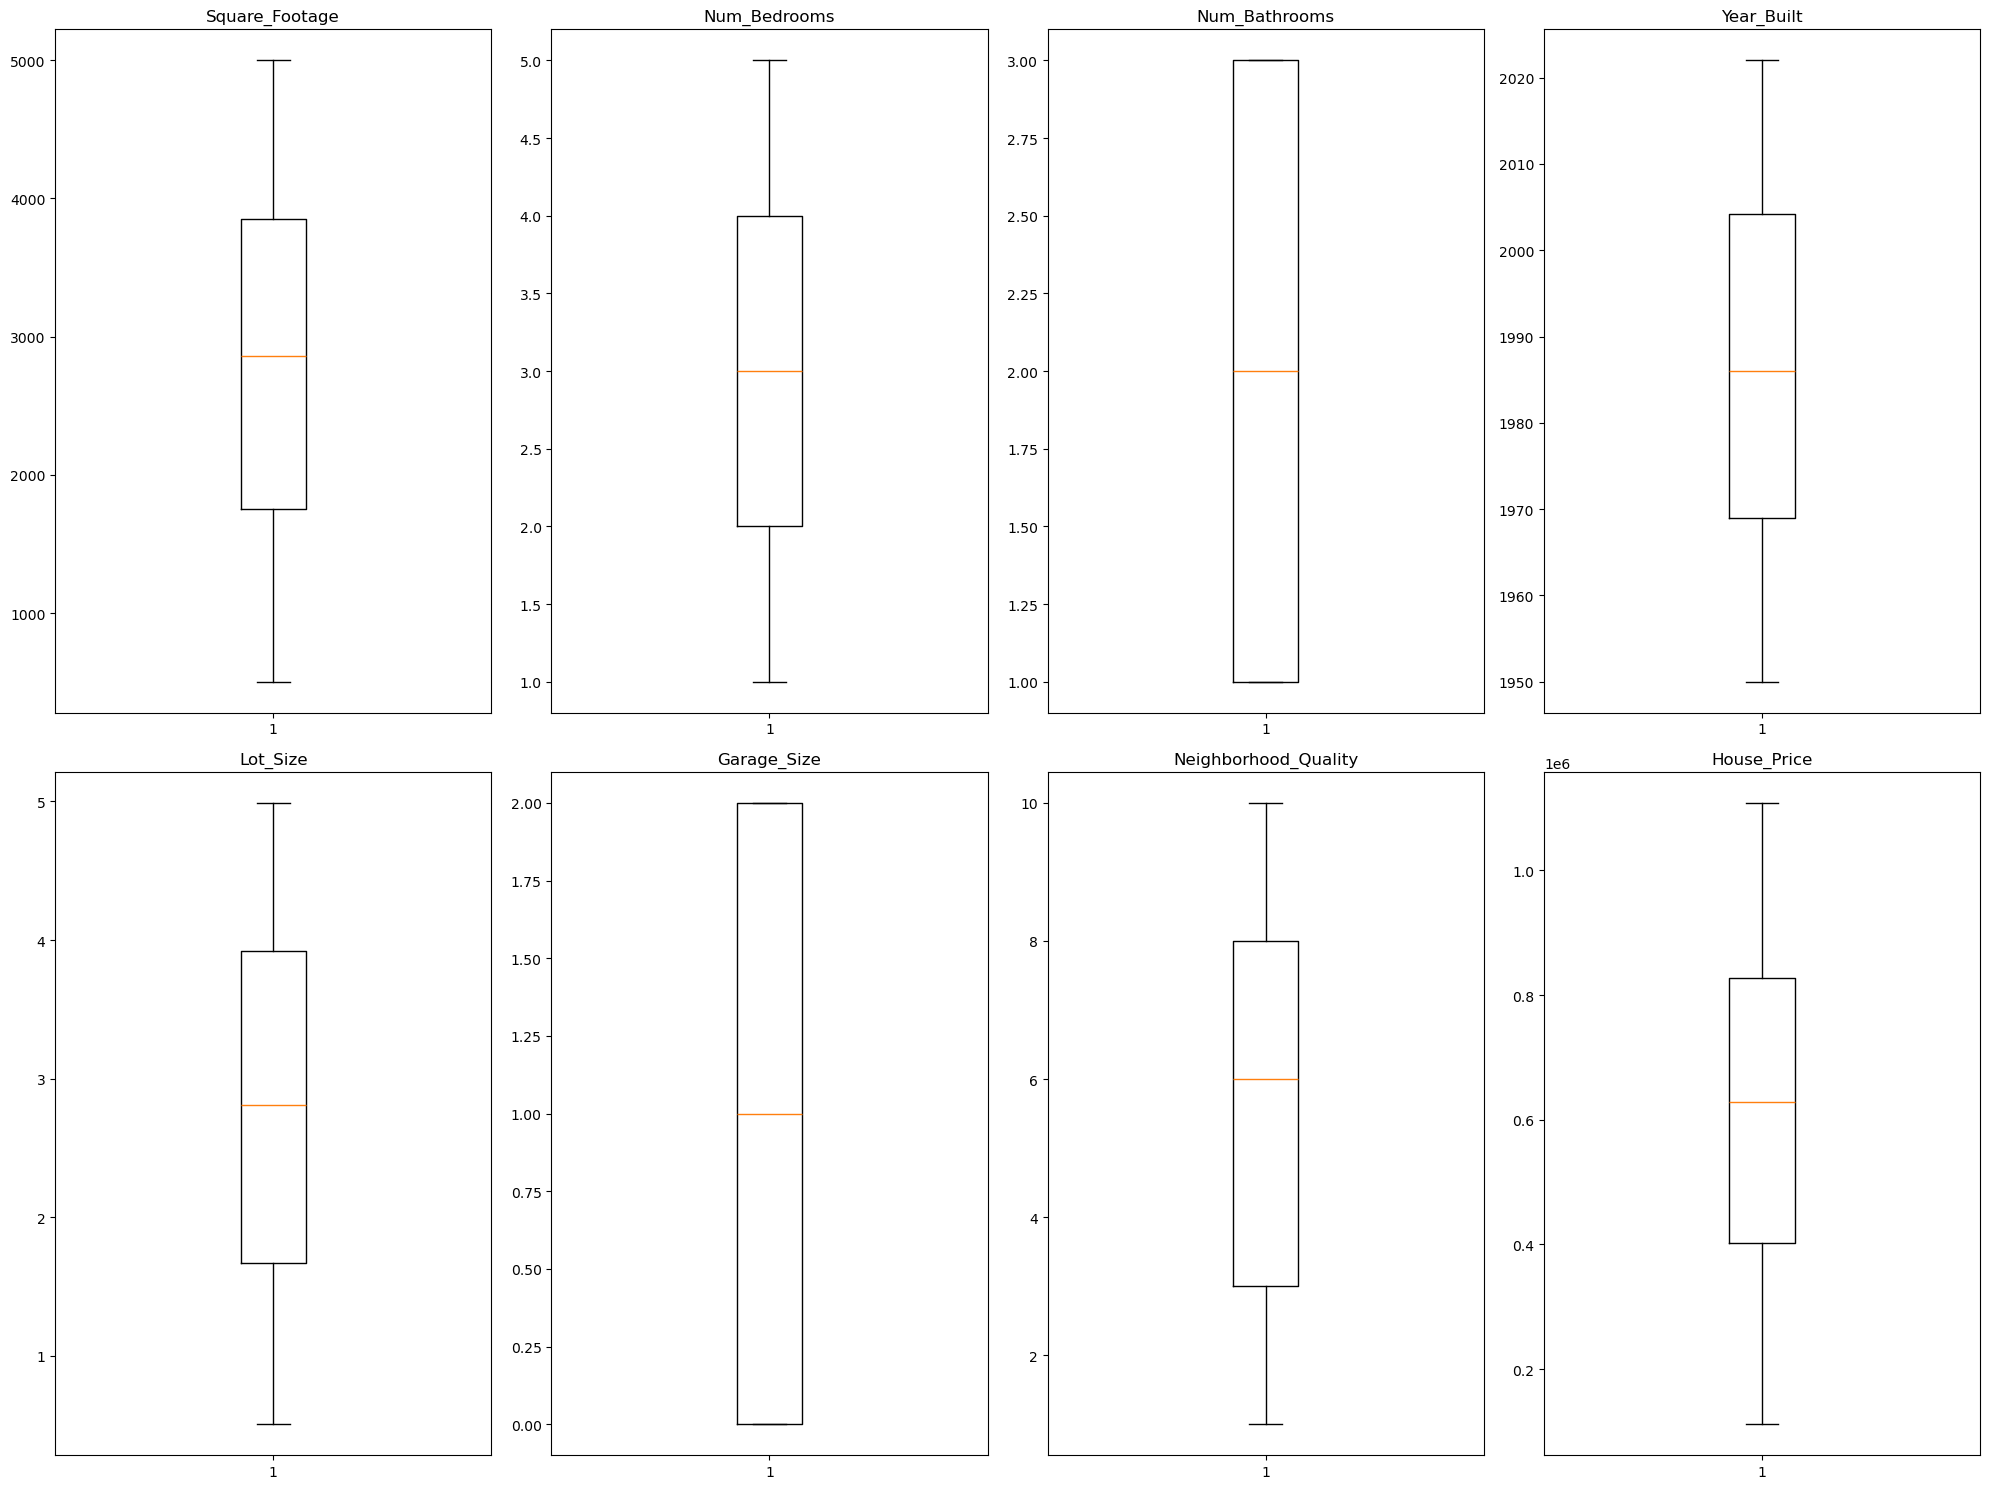

In [54]:
#Boxplot

cols = df.columns
n_col = 4
n_row = 2

plt.figure(figsize=(20, 15))
for i, col in enumerate(cols):
    plt.subplot(n_row, n_col, i+1)
    plt.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

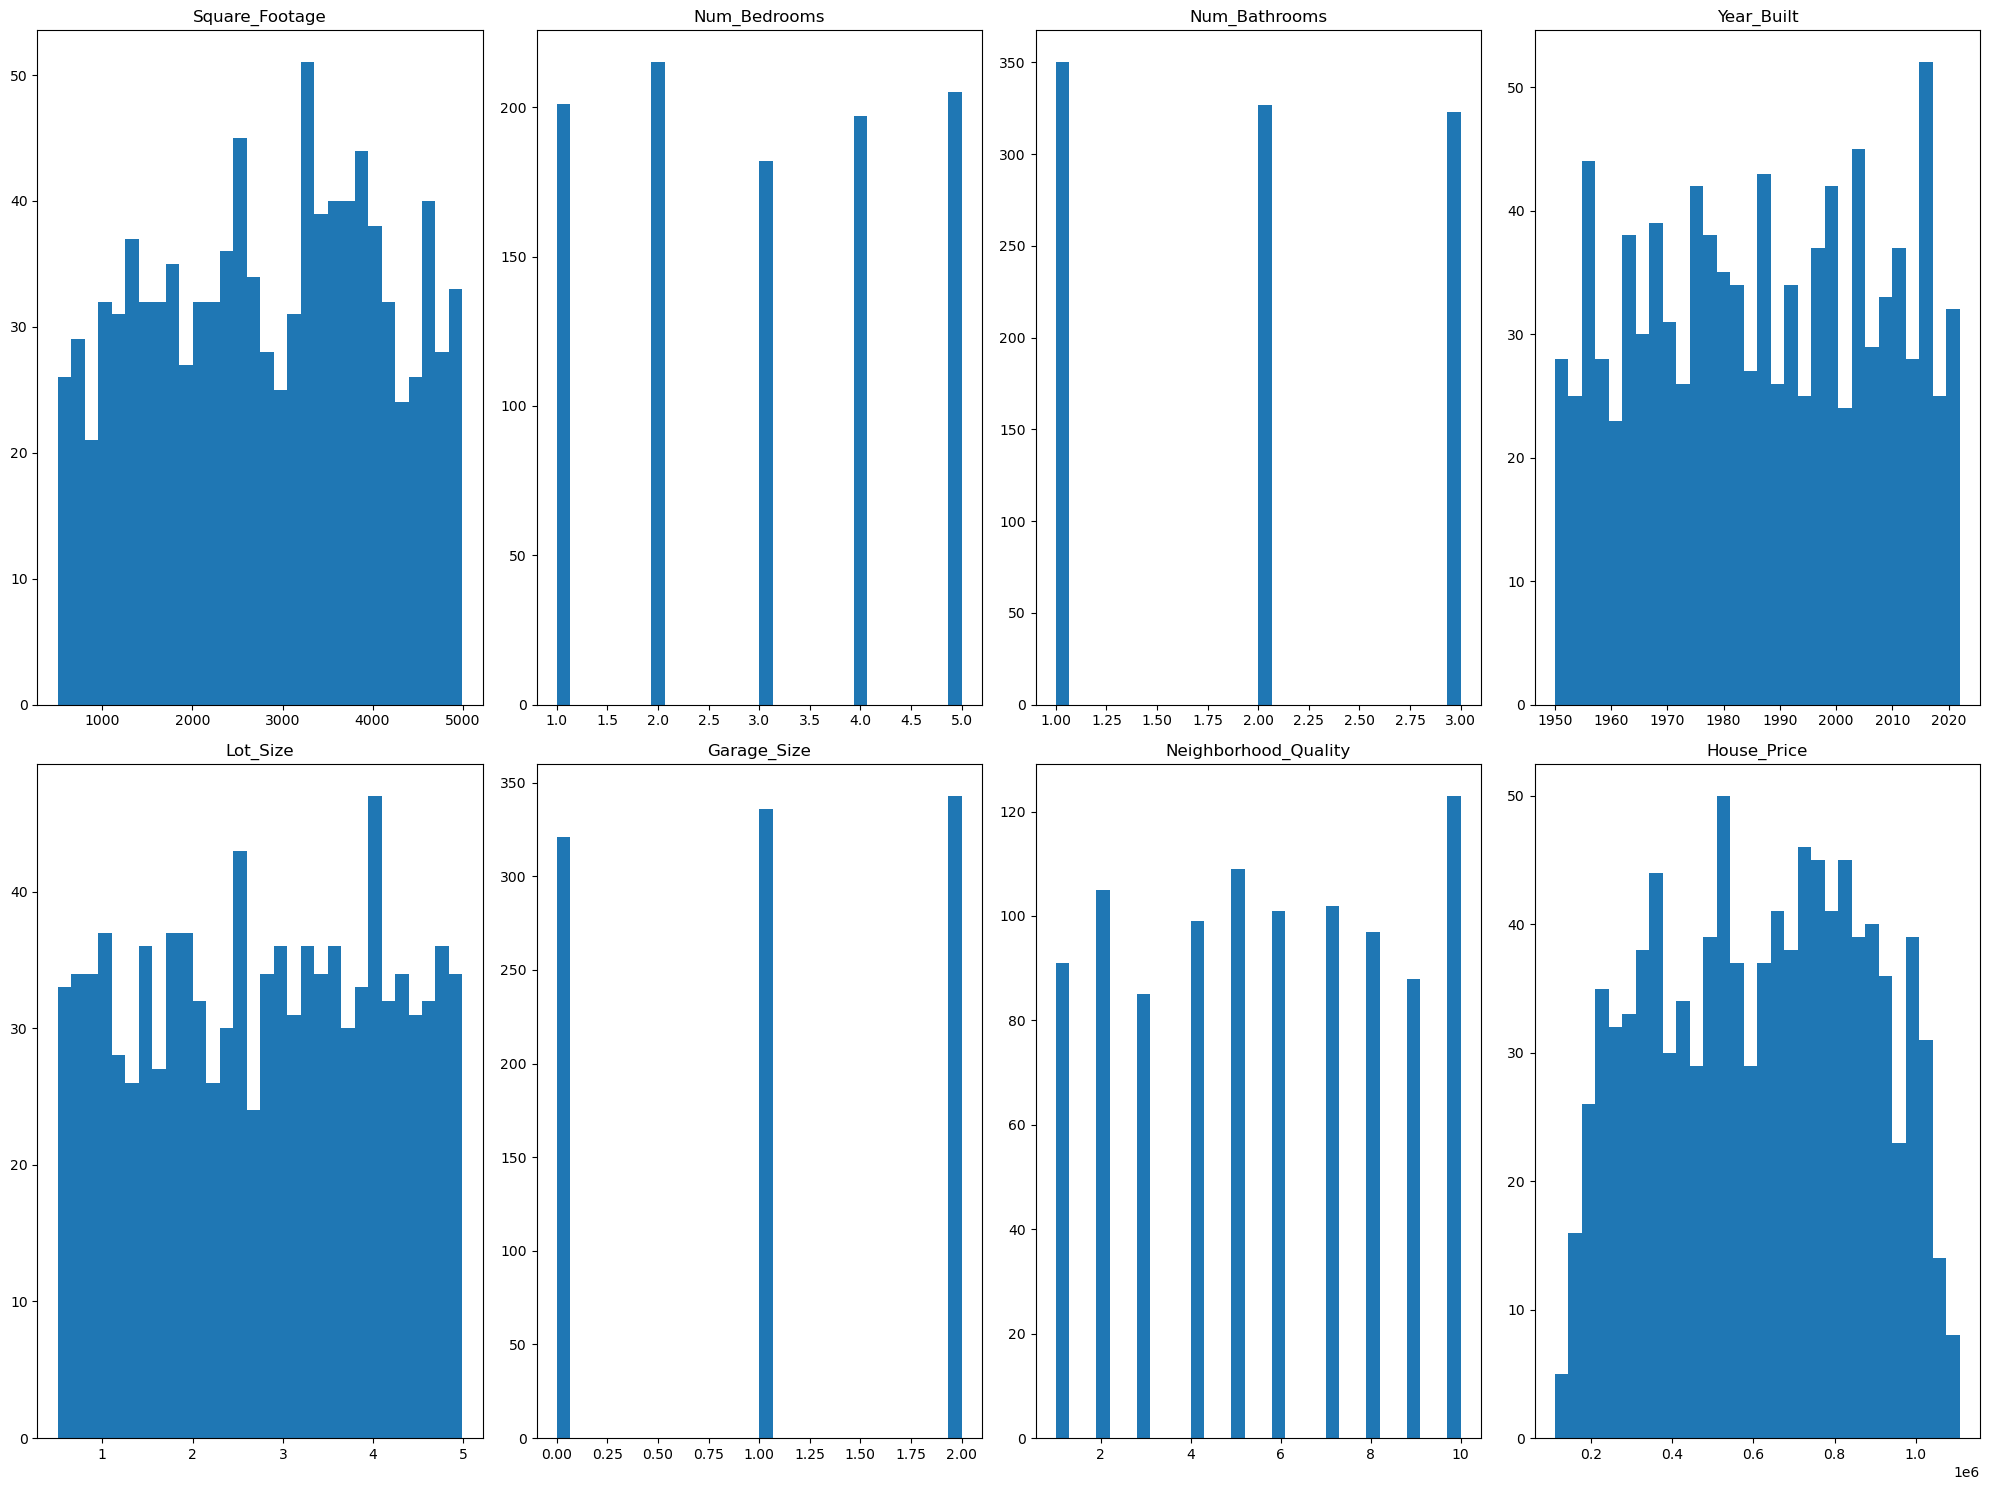

In [ ]:
#Hist

cols = df.columns
n_row = 2
n_cols = 4

plt.figure(figsize=(20, 15))
for i, col in enumerate(cols):
    plt.subplot(n_row, n_cols, i+1)
    plt.hist(df[col], bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
# Train, Test and Val

X = df.drop(columns=['House_Price'])
y = df['House_Price'].copy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
#StandardScaler

standar = StandardScaler()

X_train_scaled = standar.fit_transform(X_train)
X_test_scaled = standar.transform(X_test)
X_val_scaled = standar.transform(X_val)

X_train_scaled = pd.DataFrame(X_train_scaled)
X_test_scaled = pd.DataFrame(X_test_scaled)
X_val_scaled = pd.DataFrame(X_val_scaled)

In [ ]:
#Linear Regression - Train and Val

model = LinearRegression(n_jobs=-1)
model.fit(X_train_scaled, y_train)
y_train_pred_lr = model.predict(X_train_scaled)
y_val_pred_lr = model.predict(X_val_scaled)

print(f'R²:   {r2_score(y_train_pred_lr, y_train):.4f}')
print(f'MSE:  {mean_squared_error(y_train_pred_lr, y_train):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_train_pred_lr, y_train)):.4f}')
print(f'MAPE: {mean_absolute_percentage_error(y_train_pred_lr, y_train):.4f}\n')

print(f'R²:   {r2_score(y_val_pred_lr, y_val):.4f}')
print(f'MSE:  {mean_squared_error(y_val_pred_lr, y_val):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_val_pred_lr, y_val)):.4f}')
print(f'MAPE: {mean_absolute_percentage_error(y_val_pred_lr, y_val):.4f}')

R²:   0.9985
MSE:  93850531.9560
RMSE: 9687.6484
MAPE: 0.0156

R²:   0.9985
MSE:  90779506.8071
RMSE: 9527.8280
MAPE: 0.0158


In [ ]:
#Linear Regression - Test

y_pred = model.predict(X_test_scaled)

print(f'R²:   {r2_score(y_pred, y_test):.4f}')
print(f'MSE:  {mean_squared_error(y_pred, y_test):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_pred, y_test)):.4f}')
print(f'MAPE: {mean_absolute_percentage_error(y_pred, y_test):.4f}')

R²:   0.9983
MSE:  112090090.2042
RMSE: 10587.2608
MAPE: 0.0174


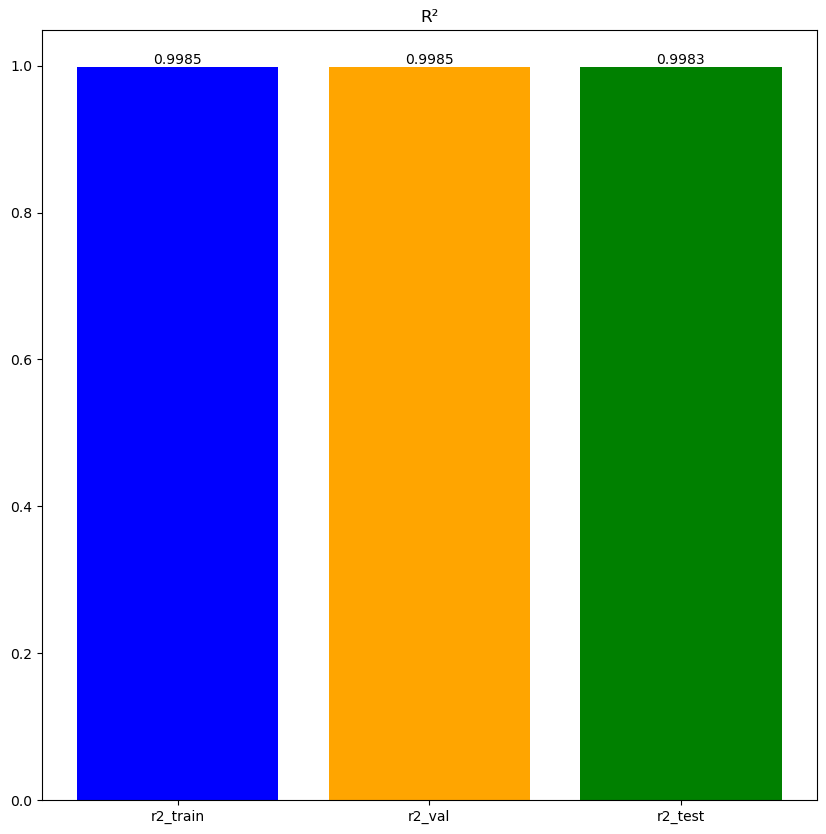

In [62]:
#Results

r2_train = r2_score(y_train_pred_lr, y_train)
r2_val = r2_score(y_val_pred_lr, y_val)
r2_test = r2_score(y_pred, y_test)

label = ['r2_train', 'r2_val', 'r2_test']
value = [r2_train, r2_val, r2_test]
color = ['blue', 'orange', 'green']

plt.figure(figsize=(10, 10))
bar = plt.bar(label, value, color=color)
plt.bar_label(bar, fmt='%.4f')
plt.title('R²')
plt.show()